# SMS SPAM CLASSIFICATION USING NLP

## CountVectorizer + TF-IDF + Multinomial Naive Bayes

## 1. Import Libraries

In [ ]:
import pandas as pd
import string
import nltk

from nltk.corpus import stopwords

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer, TfidfTransformer
from sklearn.naive_bayes import MultinomialNB
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

## 2. Download Stopwords

In [ ]:
nltk.download("stopwords", quiet=True)

STOP_WORDS = set(stopwords.words("english"))

## 3. Load Dataset

In [ ]:
messages = pd.read_csv(
    "/content/SMSSpamCollection.txt",
    sep="\t",
    names=["label", "message"]
)

print("Dataset Shape:", messages.shape)
print(messages.head())

Dataset Shape: (5572, 2)
  label                                            message
0   ham  Go until jurong point, crazy.. Available only ...
1   ham                      Ok lar... Joking wif u oni...
2  spam  Free entry in 2 a wkly comp to win FA Cup fina...
3   ham  U dun say so early hor... U c already then say...
4   ham  Nah I don't think he goes to usf, he lives aro...


## 4. Basic Data Analysis

In [ ]:
print("\nDataset Information:")
print(messages.info())

print("\nLabel Distribution:")
print(messages["label"].value_counts())

print("\nDataset Description:")
print(messages.describe())


Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5572 entries, 0 to 5571
Data columns (total 2 columns):
 #   Column   Non-Null Count  Dtype 
---  ------   --------------  ----- 
 0   label    5572 non-null   object
 1   message  5572 non-null   object
dtypes: object(2)
memory usage: 87.2+ KB
None

Label Distribution:
label
ham     4825
spam     747
Name: count, dtype: int64

Dataset Description:
       label                 message
count   5572                    5572
unique     2                    5169
top      ham  Sorry, I'll call later
freq    4825                      30


## 5. Add Message Length

In [ ]:
messages["length"] = messages["message"].apply(len)

print("\nMessage Length Statistics:")
print(messages["length"].describe())


Message Length Statistics:
count    5572.000000
mean       80.489950
std        59.942907
min         2.000000
25%        36.000000
50%        62.000000
75%       122.000000
max       910.000000
Name: length, dtype: float64


## 6. Visualize Message Length

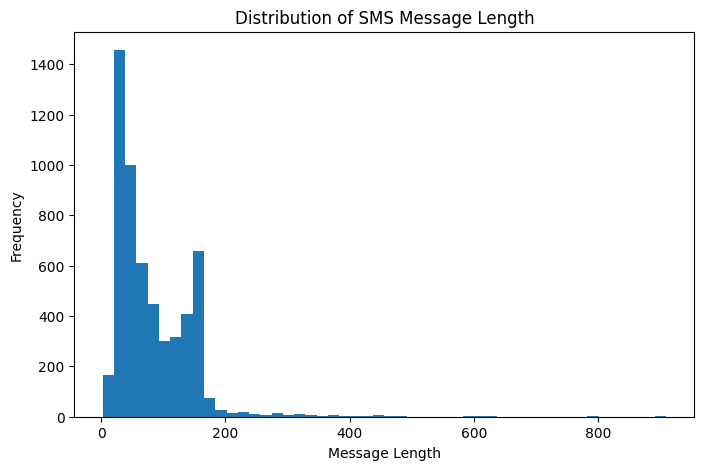

In [ ]:
plt.figure(figsize=(8, 5))

messages["length"].plot(
    bins=50,
    kind="hist"
)

plt.xlabel("Message Length")
plt.ylabel("Frequency")
plt.title("Distribution of SMS Message Length")
plt.show()

## 7. Message Length by Label

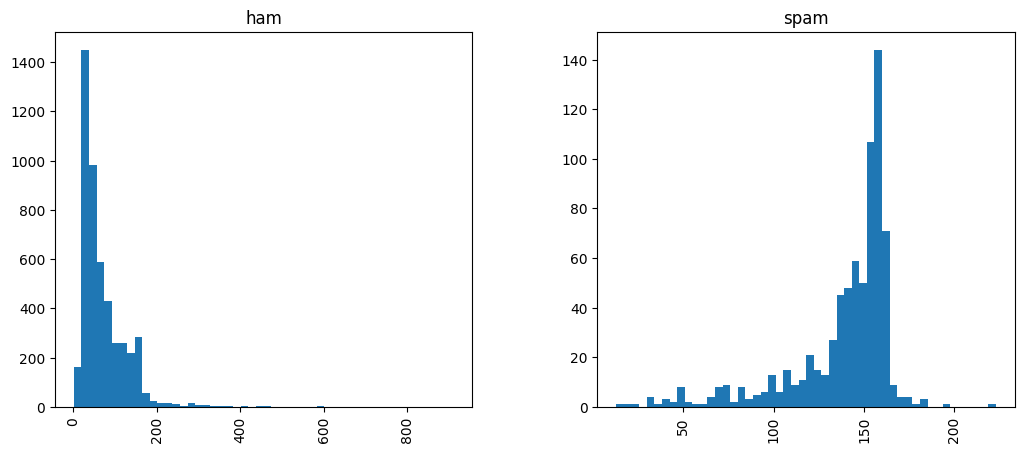

In [ ]:
messages.hist(
    column="length",
    by="label",
    bins=50,
    figsize=(12, 5)
)

plt.show()

## 8. Text Preprocessing Function

In [ ]:
def text_process(message):
    """
    Remove punctuation and stopwords
    from an SMS message.
    """

    # Remove punctuation
    no_punctuation = "".join(
        char for char in message
        if char not in string.punctuation
    )

    # Remove stopwords
    clean_words = [
        word.lower()
        for word in no_punctuation.split()
        if word.lower() not in STOP_WORDS
    ]

    return clean_words


# Test preprocessing
print("\nProcessed Example:")
print(text_process(messages["message"].iloc[0]))


Processed Example:
['go', 'jurong', 'point', 'crazy', 'available', 'bugis', 'n', 'great', 'world', 'la', 'e', 'buffet', 'cine', 'got', 'amore', 'wat']


## 9. Train-Test Split

In [ ]:
X = messages["message"]
y = messages["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=101,
    stratify=y
)

print("\nTraining Samples:", len(X_train))
print("Testing Samples:", len(X_test))


Training Samples: 4457
Testing Samples: 1115


## 10. Create NLP Pipeline

In [ ]:
pipeline = Pipeline([

    # Convert text into word-count matrix
    (
        "bow",
        CountVectorizer(
            analyzer=text_process
        )
    ),

    # Convert word counts into TF-IDF values
    (
        "tfidf",
        TfidfTransformer()
    ),

    # Naive Bayes classifier
    (
        "classifier",
        MultinomialNB()
    )
])

## 11. Train Model

In [ ]:
pipeline.fit(X_train, y_train)

print("\nModel Training Completed!")


Model Training Completed!


## 12. Make Predictions

In [ ]:
predictions = pipeline.predict(X_test)

## 13. Accuracy

In [ ]:
accuracy = accuracy_score(y_test, predictions)

print("\nAccuracy:", accuracy)


Accuracy: 0.967713004484305


## 14. Classification Report

In [ ]:
print("\nClassification Report:")
print(
    classification_report(
        y_test,
        predictions
    )
)


Classification Report:
              precision    recall  f1-score   support

         ham       0.96      1.00      0.98       966
        spam       1.00      0.76      0.86       149

    accuracy                           0.97      1115
   macro avg       0.98      0.88      0.92      1115
weighted avg       0.97      0.97      0.97      1115



## 15. Confusion Matrix

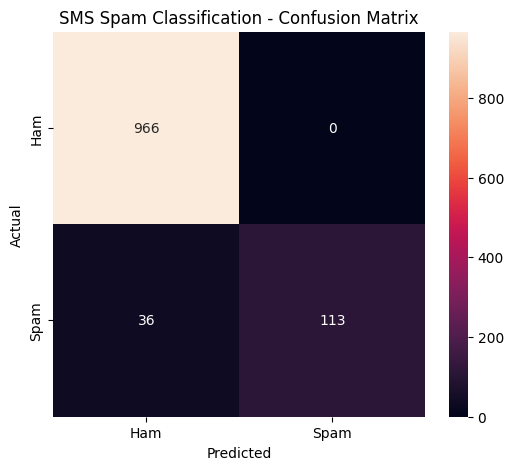

In [ ]:
cm = confusion_matrix(
    y_test,
    predictions,
    labels=["ham", "spam"]
)

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    xticklabels=["Ham", "Spam"],
    yticklabels=["Ham", "Spam"]
)

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("SMS Spam Classification - Confusion Matrix")

plt.show()

## 16. Test with Your Own Messages

In [ ]:
test_messages = [
    "Congratulations! You have won a free lottery ticket!",
    "Hey, are you coming to class today?",
    "URGENT! You have won a cash prize. Call now!",
    "Can you send me the notes?"
]

predicted_labels = pipeline.predict(test_messages)

print("\nCustom Message Predictions:")

for message, prediction in zip(test_messages, predicted_labels):
    print(f"\nMessage: {message}")
    print(f"Prediction: {prediction}")


Custom Message Predictions:

Message: Congratulations! You have won a free lottery ticket!
Prediction: ham

Message: Hey, are you coming to class today?
Prediction: ham

Message: URGENT! You have won a cash prize. Call now!
Prediction: spam

Message: Can you send me the notes?
Prediction: ham
